### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 9</center>
---

### Overview

The objective of this exercise is to study the discrete Fourier transform (DFT) of images as a basis for filtering and restoration. The DFT of a discrete image function $f(x,y)$ of size $M \times N$ (from section 4.4.1) is given by:

$$F(u,v) = \dfrac{1}{MN}\sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x,y)\, e^{-j 2\pi\, \left(ux/M\,+\,vy/N \right)}$$

This equation has to be evaluated for the discrete variables $u = 0,1,\dots,M-1$ and $v = 0,1,\dots,N-1$, which are the transform or frequency variables (the coordinates in the frequency domain). The magnitude $|F(u,v)|$ is called the Fourier spectrum or just spectrum:

$$|F(u,v)| = \left[\mathrm{Re}\{F(u,v)\}^2 + \mathrm{Im}\{F(u,v)\}^2\right]^\frac{1}{2}$$

The phase angle is given by:

$$\Phi(u,v) = \mathrm{atan2}\dfrac{\mathrm{Im}\{F(u,v)\}}{\mathrm{Re}\{F(u,v)\}}$$

Using the spectrum and phase angle, $F(u,v)$ can also be written as:

$$F(u,v) = |F(u,v)|\, e^{j\Phi}$$

The inverse discrete Fourier transform (IDFT) is given by:

$$f(x,y) = \sum_{u=0}^{M-1}\sum_{v=0}^{N-1} F(u,v)\, e^{j 2\pi\, \left(ux/M\,+\,vy/N \right)}$$

This equation has to be evaluated for the discrete variables $x = 0,1,\dots,M-1$ and $y = 0,1,\dots,N-1$. The two equations form a 2D discrete Fourier transform pair. Note that the summations in both equations are taken over *all* values of $f(x,y)$ and $F(u,v)$, respectively.

To be able to interpret the spectrum of an image, it is often helpful to use a log transformation (see task sheet 3). This function is already provided for convenience here.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

In [2]:
# based on the log transformation from task sheet 4
def log_transformation(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    for iy in range(rows):
        for jx in range(cols):
            c = 255 / np.log(1 + np.amax(img)) # normalize result to 255*[0,1]
            res[iy, jx] = c * np.log(1 + img[iy, jx]) # min of log = 0, max = np.log(1 + img[i, j])
            
    # return result
    return res

#### <span style="color: RoyalBlue; font-weight: bold;">Task 9.1</span> Discrete Fourier Transform

The formulas for the DFT and IDFT contain complex numbers. Numpy and Python directly support <a href="https://numpy.org/doc/stable/reference/routines.math.html#handling-complex-numbers">`complex numbers` ↗</a>, where the imaginary unit is denoted by `j`. In general, complex numbers are a built-in data type in Python and can be defined using <a href="https://docs.python.org/3/library/functions.html#complex">`complex` ↗</a>. Alternatively, two images can be used: one for the real part and one for the imaginary part. These two images can then be computed based on Euler's formula (multiplying with sines and cosines instead of the complex exponential functions).

The naive implementation of the formulas from the overview is slow and therefore usually not recommended. It is considered here for training purposes only. Later, Numpy or OpenCV can be used (the results are always the same, but Numpy uses complex images and OpenCV two-channel images to store the real and imaginary parts, see this <a href="https://docs.opencv.org/master/de/dbc/tutorial_py_fourier_transform.html">`OpenCV tutorial` ↗</a> on the Fourier transform). In this exercise we use Numpy.

Implement / solve the following tasks:

1. Write a function to compute the DFT for a given image using the (naive) formula from the overview.
2. Use this function to compute $F(u, v)$ for the image *rectangle-small.png*.
3. Compute the mean value of the image and compare it with $F(0, 0)$.
4. Compute the spectrum of the image and plot the log normalized result.
5. Extend the function so that the DFT is shifted to the center by multiplying the image with $(-1)^{(x+y)}$ before the transform (parameter `shift`).
6. Use the extended function to compute the shifted spectrum and plot the log normalized result.
7. Compute the spectrum using Numpy (see the <a href="https://docs.opencv.org/master/de/dbc/tutorial_py_fourier_transform.html">`OpenCV tutorial` ↗</a>) and compare it with the naive implementation (compare the spectra after log normalization).

*Note*: The image *rectangle-small.png* is small ($50 \times 50\,\text{px}$) because the naive implementation of the formulas from the overview is slow.

In [3]:
# example to define a complex number
a = complex(1, -2) # corresponds to a = 1-2j
print(a)

(1-2j)


In [4]:
# compute DFT for given image
def dft(img, shift=False):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.complex64) # init with zeros, note the complex datatype
    
    # create copy of input image so that the input is not modified
    img_in = img.copy().astype(dtype=np.float64)
    
    # multiply image by (-1)^(x+y) before the transform to shift F(u, v) to the center
    if shift:
        for ix in range(rows):
            for jy in range(cols):
                img_in[ix, jy] = img_in[ix, jy] * ((-1)**(ix+jy))

    # naive formula for the DFT from above (can be accelerated using separability of the 2D DFT)
    for iu in range(rows):
        for jv in range(cols):
            for ix in range(rows):
                for jy in range(cols):
                    res[iu, jv] = res[iu, jv] + img_in[ix, jy]*np.exp(complex(0, -2*np.pi*(iu*ix/rows + jv*jy/cols)))
    
        # print some status information (let's say: row info)
        print("row = " + str(iu), end='\r') # current row
            
    # normalization (1/M*N)
    res = res / (rows*cols)

    # return result
    return res

Input:


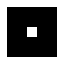

In [44]:
# read the image as a grayscale image (parameter 0) and plot it
img = cv2.imread('images/rectangle-small.png', 0)
print("Input:")
plot_img_orig(img)

In [6]:
# compute DFT
img_dft = dft(img)
#print(img_dft)

Spectrum:


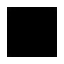

In [7]:
# compute the spectrum |F(u, v)|
img_spec = np.absolute(img_dft)
print("Spectrum:")
plot_img_orig(img_spec)
#print(spec)

Normalization:


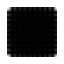

In [8]:
# normalization of |F(u, v)|
img_spec_n = cv2.normalize(img_spec, None, 0, 255, cv2.NORM_MINMAX)
print("Normalization:")
plot_img_orig(img_spec_n)

Shift and normalization:


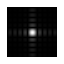

In [9]:
# shift origin of F(u, v) to the frequency coordinates (M/2, N/2)
img_dft_shift = dft(img, True)
img_spec_shift = np.absolute(img_dft_shift)
img_spec_shift_n = cv2.normalize(img_spec_shift, None, 0, 255, cv2.NORM_MINMAX)
print("Shift and normalization:")
plot_img_orig(img_spec_shift_n)

Shift and log transformation:


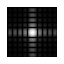

In [10]:
# log transformation
img_spec_shift_log = log_transformation(img_spec_shift)
print("Shift and log transformation:")
plot_img_orig(img_spec_shift_log)

In [11]:
# mean value of the input image
m_img = np.mean(img)
print("Image mean = " + str(m_img) + ", F(0, 0) = " + str(img_dft[0, 0]))

Image mean = 10.2, F(0, 0) = (10.2+0j)


In [12]:
# comparison with Numpy
rows, cols = img.shape # image size
img_dft = np.fft.fft2(img)/(rows*cols) # compute FFT and normalize (normalization only for comparison)
img_dft_shift = np.fft.fftshift(img_dft) # shift FFT to the center

Shift and log transformation of Numpy FFT:


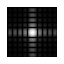

In [13]:
# log transformation of Numpy result
img_spec_shift = np.absolute(img_dft_shift)
img_spec_shift_log = log_transformation(img_spec_shift)
print("Shift and log transformation of Numpy FFT:")
plot_img_orig(img_spec_shift_log)

As can be seen, multiplying the image with $(-1)^{(x+y)}$ before the transform shifts the spectrum to the center of the image. For a better interpretation of the spectrum, the log transformation is helpful. The pattern of the spectrum corresponds to (normalized) $\text{sinc}$ functions (sinus cardinalis), because a box in the spatial domain corresponds to a $\text{sinc}$ in the frequency domain.

The value $F(0, 0)$ (top left in the unshifted spectrum) corresponds to the mean value of the input image and is typically the largest value of the spectrum. The results of the manual implementation are identical to Numpy, but Numpy is much faster. This is because Numpy uses the Fast Fourier Transform (FFT), which uses a specific divide-and-conquer strategy of the input image (data) to compute the DFT. Therefore, the naive implementation should not be used.

The naive implementation can be accelerated by using the separability of the 2D DFT (by first computing a 1D transform as an intermediate result along each row, and then compute a 1D transform along each column of this intermediate result).

#### <span style="color: RoyalBlue; font-weight: bold;">Task 9.2</span> Inverse Discrete Fourier Transform (IDFT)

The inverse discrete Fourier transform can be computed using the formula from the overview (eq. 4.18). In this case, it has to be considered if the spectrum has been shifted to the center. If the original Fourier transform is used, the IDFT can be computed directly. If the spectrum has been shifted to the center, it can either be shifted back at first or the result can again be multiplied with $(-1)^{(x+y)}$.

The result of the IDFT is the original image $f(x,y)$, which should be real. Nonetheless, due to rounding errors, the result after the IDFT usually contains parasitic imaginary parts. Therefore, the actual result can be computed by taking the real values. These can also contain rounding errors and are therefore often no perfect integer values (these can be obtained by rounding or type conversion).

Implement / solve the following tasks:

1. Write a function to compute the IDFT for a given Fourier transform $F(u, v)$ using the (naive) formula from the overview.
2. Compute the IDFT for $F(u, v)$ from the previous task.
3. Compute the IDFT using Numpy (see the OpenCV tutorial ↗) and compare it with the naive implementation (compare the result images).

In [34]:
# compute IDFT (compute image based on the frequency representation)
def idft(img_dft):
    # create empty image
    rows, cols = img_dft.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.complex64) # init with zeros, note the complex datatype

    # naive formula for the IDFT from above (can be accelerated using separability of the 2D DFT)
    for ix in range(rows):
        for jy in range(cols):
            for iu in range(rows):
                for jv in range(cols):
                    res[ix, jy] = res[ix, jy] + img_dft[iu, jv]*np.exp(complex(0, 2*np.pi*(iu*ix/rows + jv*jy/cols)))

        # print some status information
        print("row = " + str(ix), end='\r') # current row
        
    # get only real part and convert format
    res = np.real(res)
    res = res.astype(dtype=np.uint8)

    # return result
    return res

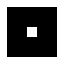

In [35]:
# compute IDFT using the unshifted spectrum (otherwise shift it back)
img_idft = idft(img_dft)
img_idft = np.real(img_idft)
plot_img_orig(img_idft)

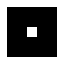

In [39]:
# comparison with Numpy
img_dft_backshift = np.fft.ifftshift(img_dft_shift)
img_idft = np.fft.ifft2(img_dft_backshift)
img_idft = np.real(img_idft)*(rows*cols) # ifft2 includes normalization, but here we have aleready normalized in DFT
plot_img_orig(img_idft)

The results of the manual implementation are identical to Numpy, but Numpy is much faster. This is because Numpy uses the Inverse Fast Fourier Transform (IFFT). Furthermore, the normalization term ($1/MN$) is included in the inverse transform (which is standard in many programming langues, in the overview it is in the normal transform). As we have done a manual normalization before, we need to multiply the result by $MN$.

In summary, the following Numpy functions can be used to transform and images to the frequency domain and back:

original image is back after FFT and IFFT: 


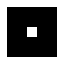

In [52]:
# normal (forward) DFT
img_dft = np.fft.fft2(img) # compute DFT (no normalization to 1/MN)
img_dft_shift = np.fft.fftshift(img_dft) # shift FFT to the center
img_spec_shift = np.absolute(img_dft_shift)
img_spec_shift_log = log_transformation(img_spec_shift)

# inverse DFT (IDFT)
img_dft_backshift = np.fft.ifftshift(img_dft_shift) # shift centered FFT back to top left
img_idft = np.fft.ifft2(img_dft_backshift) # compute IDFT
img_back = np.real(img_idft) # take only real part, as all imaginary parts are parasitic
print('original image is back after FFT and IFFT: ')
plot_img_orig(img_back)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 9.3</span> Some Properties of the DFT and Spectrum

To analyze some properties of the DFT and the spectrum, the images *rectangle1.png* - *rectangle7.png* can be used. The images contain different rectangles which have been specifically constructed.

Implement / solve the following tasks:

1. Compute the DFT for all images and shift them to the center.
2. Compute the spectrum of these DFTs and apply the log transformation.
3. Plot and analyze the results.

In [53]:
def compute_dft_and_save_log_normalized_spectrum(img_path):
    # read image as a grayscale images (parameter 0)
    img = cv2.imread(img_path, 0)

    #1 compute the DFT and shift it to the center
    img_dft = np.fft.fft2(img) # compute DFT (no normalization to 1/MN)
    img_dft_shift = np.fft.fftshift(img_dft) # shift FFT to the center
    
    #2 Spectrum and log transformation
    img_spec_shift = np.absolute(img_dft_shift)
    img_spec_shift_log = log_transformation(img_spec_shift)
    
    #3 Plot and save the result as an image
    filename = img_path.split("/", 1)[1] # get filename (everything after the slash), (,1 for 1 element after slash)
    #, [1] for last splitted element, [0] for first splitted element
    filename = "output/spec_" + filename
    cv2.imwrite(filename, img_spec_shift_log)

In [54]:
# use the function from above to compute and save the spectrum
compute_dft_and_save_log_normalized_spectrum("images/rectangle1.png")

In [55]:
compute_dft_and_save_log_normalized_spectrum("images/rectangle2.png")
compute_dft_and_save_log_normalized_spectrum("images/rectangle3.png")
compute_dft_and_save_log_normalized_spectrum("images/rectangle4.png")
compute_dft_and_save_log_normalized_spectrum("images/rectangle5.png")
compute_dft_and_save_log_normalized_spectrum("images/rectangle6.png")
compute_dft_and_save_log_normalized_spectrum("images/rectangle7.png")

<table align="left">
<tr>
    <td><img src="images/rectangle1.png"></td>
    <td><img src="output/spec_rectangle1.png"></td>
    <td>rectangle1.png</td>
</tr>
    <tr>
    <td><img src="images/rectangle2.png"></td>
    <td><img src="output/spec_rectangle2.png"></td>
    <td>rectangle2.png</td>
</tr>
<tr>
    <td><img src="images/rectangle3.png"></td>
    <td><img src="output/spec_rectangle3.png"></td>
    <td>rectangle3.png</td>
</tr>
<tr>
    <td><img src="images/rectangle4.png"></td>
    <td><img src="output/spec_rectangle4.png"></td>
    <td>rectangle4.png</td>
</tr>
<tr>
    <td><img src="images/rectangle5.png"></td>
    <td><img src="output/spec_rectangle5.png"></td>
    <td>rectangle5.png</td>
</tr>
<tr>
    <td><img src="images/rectangle6.png"></td>
    <td><img src="output/spec_rectangle6.png"></td>
    <td>rectangle6.png</td>
</tr>
<tr>
    <td><img src="images/rectangle7.png"></td>
    <td><img src="output/spec_rectangle7.png"></td>
    <td>rectangle7.png</td>
</tr>
</table>

Comparing the spectra of *rectangle1.png* and *rectangle2.png* shows the inverse relationship between the structure size in the spatial and frequency domain: the size of the square has doubled, while the distance between the zeros (black) has only half of the previous size.

Comparing the spectra of *rectangle2.png* and *rectangle3.png* shows that the vertical and horizontal extension of the rectangle is also represented in the spectrum: In *rectangle2.png*, the frequency in the horizontal direction (from left to right) is higher than from top to bottom (the gray values change faster when going along a scan line in the center of the image), therefore the spectrum has higher values in the horizontal direction and larger distances between the zeros.

Comparing the spectra of *rectangle4.png* and *rectangle5.png* shows that $|F(u, v)|$ is invariant to translations (because $f(x-x_0, y-y_0) \Leftrightarrow F(u, v)\, e^{-j 2\pi (x_0 u/M + y_0 v /N)}$ and $|e^{-j 2\pi (x_0 u/M + y_0 v /N)}| = 1$).

Comparing the spectra of *rectangle4.png* and *rectangle6.png* shows that the spectrum rotates by the same angle of the image.

Analyzing the spectrum of *rectangle7.png* shows that the interruptions in the horizontal direction are also represented in the spectrum. The bars are now even smaller than before so that the distance between the zeros in the spectrum has increased. Also note that the distance between the zeros in the horizontal direction is not constant any more, because the areas to the left and right of the pattern can be viewed as large black bars that are smaller than the intermediate black bars.

It becomes clear that even though it is often difficult to interpret the spectrum of an image, there is a direct relation between the image content and the corresponding spectrum.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 9.4</span> Spectrum and Phase Interpretation

In order to obtain further information on the significance of the spectrum and the phase of the Fourier transform, some more analyses should be carried out.

Implement / solve the following tasks:

1. Compute the phase angles of the images *rectangle4.png* and *rectangle5.png*, plot the corresponding phase angle images using normalization, and compare the results.
2. Compute, plot and analyze the log normalized spectra of the images *pollen.png* and *waves.png*.
3. Reconstruct the image *pollen.png* only based on the phase angle (set $F(u, v) = 1$) and only based on the spectrum (set $\Phi(u, v) = 0$) and analyze the results.

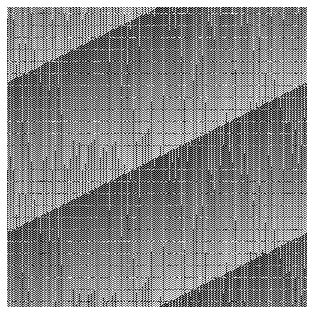

In [22]:
# rectangle4.png
r4 = cv2.imread('images/rectangle4.png', 0) # read image as a grayscale images (parameter 0)
r4_dft = np.fft.fft2(r4) # compute DFT (no normalization to 1/MN)
r4_dft_shift = np.fft.fftshift(r4_dft) # shift FFT to the center
r4_angle = np.angle(r4_dft_shift) # compute the phase image
r4_angle_n = cv2.normalize(r4_angle, None, 0, 255, cv2.NORM_MINMAX) # normalize the phase image
plot_img_orig(r4_angle_n)

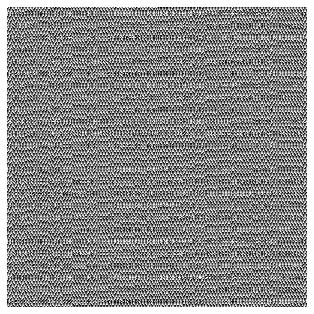

In [23]:
# rectangle5.png
r5 = cv2.imread('images/rectangle5.png', 0) # read image as a grayscale images (parameter 0)
r5_dft = np.fft.fft2(r5) # compute DFT (no normalization to 1/MN)
r5_dft_shift = np.fft.fftshift(r5_dft) # shift FFT to the center
r5_angle = np.angle(r5_dft_shift) # compute the phase image
r5_angle_n = cv2.normalize(r5_angle, None, 0, 255, cv2.NORM_MINMAX) # normalize the phase image
plot_img_orig(r5_angle_n)

As can be seen, the phase angle images can hardly be interpreted intuitively. For example, the phase angle image for *rectangle4.png* does *not* correspond to the rotated rectangle. The spectra of *rectangle4.png* and *rectangle5.png* are the same, even though the input images are different (the rectangle is at the bottom instead of at the center). It is clear that the phase angles must be different then (in other words, the translation of the rectangle is represented by the phase angle).

In [24]:
# waves.png
compute_dft_and_save_log_normalized_spectrum("images/waves.png")

In [25]:
# pollen.png
compute_dft_and_save_log_normalized_spectrum("images/pollen.png")

In [26]:
# compute DFT of pollen to get spectrum and angle
pollen = cv2.imread('images/pollen.png', 0) # read image as a grayscale images (parameter 0)
pollen_dft = np.fft.fft2(pollen)
pollen_spec = np.absolute(pollen_dft)
pollen_angle = np.angle(pollen_dft)

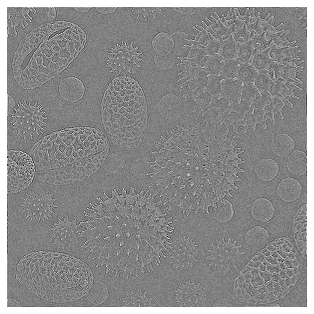

In [27]:
# reconstruction only based on the phase angle
pollen_angle = np.exp(complex(0, 1)*pollen_angle) # F(u, v) = 1, this multiplication can be skipped
pollen_angle_idft = np.fft.ifft2(pollen_angle) # compute IDFT
pollen_angle_back = np.real(pollen_angle_idft)
pollen_angle_back_n = cv2.normalize(pollen_angle_back, None, 0, 255, cv2.NORM_MINMAX) # normalize the phase image
plot_img_orig(pollen_angle_back_n)

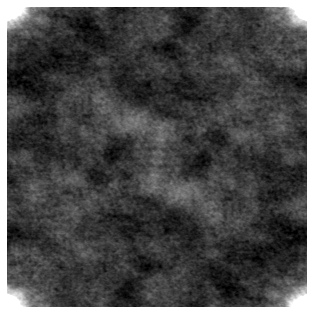

In [28]:
# reconstruction only based on the spectrum
pollen_spec_idft = np.fft.ifft2(pollen_spec) # compute IDFT only based in spectrum (Phi = 0)
pollen_spec_back = np.real(pollen_spec_idft)
plot_img_orig(pollen_spec_back)

<table align="left">
<tr>
    <td><img src="images/waves.png"></td>
    <td><img src="output/spec_waves.png"></td>
    <td>waves.png</td>
</tr>
    <tr>
    <td><img src="images/pollen.png"></td>
    <td><img src="output/spec_pollen.png"></td>
    <td>pollen.png</td>
</tr>
</table>

The reconstruction of the image *pollen.png* only based on the phase angle shows that the shape characteristics of an image are represented by the phase angle. The intensity information are represented by the spectrum, which are missing here completely. On the other hand, the reconstruction based on the spectrum is missing shape features completely.

The spectrum of the image *waves.png* shows that regular waves are represented by only a few components in the spectrum. This is because the waves have been computed using the wave vector with given frequencies (see task sheet 3). If the goal is to remove these waves, the corresponding points in the spectrum can simply be filtered out, which would be much more difficult in the spatial domain.